In [84]:
%pip install -q numpy pandas scikit-learn matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Stage 1: The ML Lifecycle in Action -- Data Ingestion Through Preprocessing

## STEP 1 -- Reproducibility Setup (5 minutes)

In [ ]:
# STEP 1: Reproducibility setup
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Fix all sources of randomness BEFORE any data generation or splitting
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed locked to {SEED}")
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")

Random seed locked to 42
NumPy version: 2.3.4
pandas version: 2.3.3


## STEP 2 -- Data Ingestion: Generating the TalentFlow Dataset (10 minutes)

In [ ]:
# STEP 2: Data ingestion -- generate synthetic TalentFlow HR dataset
n_employees = 600

data = {
    "employee_id": np.arange(1, n_employees + 1),
    "age": np.random.randint(22, 62, size=n_employees),
    "years_at_company": np.random.randint(0, 30, size=n_employees),
    "distance_from_home": np.random.randint(1, 50, size=n_employees),
    "satisfaction_score": np.random.uniform(1.0, 5.0, size=n_employees).round(2),
    "Yearly_hours": np.random.normal(loc=170, scale=20, size=n_employees).round(1),
    "num_projects": np.random.randint(1, 8, size=n_employees),
    "department": np.random.choice(
        ["Engineering", "Sales", "HR", "Marketing"], size=n_employees, p=[0.4, 0.3, 0.15, 0.15]
    ),
    "overtime": np.random.choice([0, 1], size=n_employees, p=[0.6, 0.4]),
}

base_income = (
    25000
    + data["age"] * 300
    + data["years_at_company"] * 500
    + data["num_projects"] * 400
    + np.where(np.array(data["department"]) == "Engineering", 5000, 0)
    + np.random.normal(0, 2000, size=n_employees)
)
data["Yearly_income"] = np.clip(base_income, 20000, 80000).round(2)

attrition_score = (
    -0.5 * data["satisfaction_score"]
    + 0.03 * data["distance_from_home"]
    + 0.8 * data["overtime"]
    - 0.02 * data["years_at_company"]
    + 0.01 * data["Yearly_hours"]
    + np.random.normal(0, 0.3, size=n_employees)
)
attrition_prob = 1 / (1 + np.exp(-attrition_score))
data["attrition"] = (attrition_prob > 0.80).astype(int)

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
print(f"Attrition rate: {df['attrition'].mean():.2%}")
df.head(10)

Dataset shape: (600, 11)
Attrition rate: 31.50%


,employee_id,age,years_at_company,distance_from_home,satisfaction_score,monthly_hours,num_projects,department,overtime,monthly_income,attrition
0,1,48,19,20,3.39,175.4,7,Sales,0,55829.10,0
1,2,45,21,5,4.24,152.0,1,Marketing,0,49553.01,0
2,3,34,9,23,4.20,143.4,3,Sales,0,40909.27,0
3,4,47,21,9,4.73,165.2,3,Sales,0,52564.05,0
4,5,50,18,29,4.08,151.1,2,HR,1,49799.86,0
5,6,49,29,16,3.99,178.2,5,Engineering,1,63443.35,0
6,7,49,20,46,1.94,196.0,4,Engineering,0,55555.84,1
7,8,29,27,22,1.24,222.0,3,Marketing,0,47452.72,1
8,9,44,2,8,3.07,176.8,3,Marketing,0,38439.45,0
9,10,50,10,20,1.50,182.9,4,Marketing,1,50300.09,1


## STEP 3 -- Exploratory Data Analysis (12 minutes)

In [88]:
# STEP 3a: Basic profiling
print(df.info())
print("\n--- Descriptive Statistics ---")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         600 non-null    int64  
 1   age                 600 non-null    int32  
 2   years_at_company    600 non-null    int32  
 3   distance_from_home  600 non-null    int32  
 4   satisfaction_score  600 non-null    float64
 5   monthly_hours       600 non-null    float64
 6   num_projects        600 non-null    int32  
 7   department          600 non-null    object 
 8   overtime            600 non-null    int64  
 9   monthly_income      600 non-null    float64
 10  attrition           600 non-null    int64  
dtypes: float64(3), int32(4), int64(3), object(1)
memory usage: 42.3+ KB
None

--- Descriptive Statistics ---


,employee_id,age,years_at_company,distance_from_home,satisfaction_score,monthly_hours,num_projects,overtime,monthly_income,attrition
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000
mean,300.500000,41.498333,14.491667,24.193333,2.992200,170.449667,4.055000,0.375000,48229.04930,0.315000
std,173.349358,11.594426,8.446429,14.140103,1.149031,19.045143,1.956618,0.484527,6664.53324,0.464903
min,1.000000,22.000000,0.000000,1.000000,1.010000,113.600000,1.000000,0.000000,31399.15000,0.000000
25%,150.750000,32.000000,7.000000,12.000000,2.060000,157.400000,2.000000,0.000000,43441.98750,0.000000
50%,300.500000,42.000000,14.000000,24.000000,2.990000,170.700000,4.000000,0.000000,47870.25000,0.000000
75%,450.250000,51.000000,22.000000,37.000000,4.010000,183.850000,6.000000,1.000000,52944.97000,1.000000
max,600.000000,61.000000,29.000000,49.000000,4.990000,226.000000,7.000000,1.000000,65046.24000,1.000000


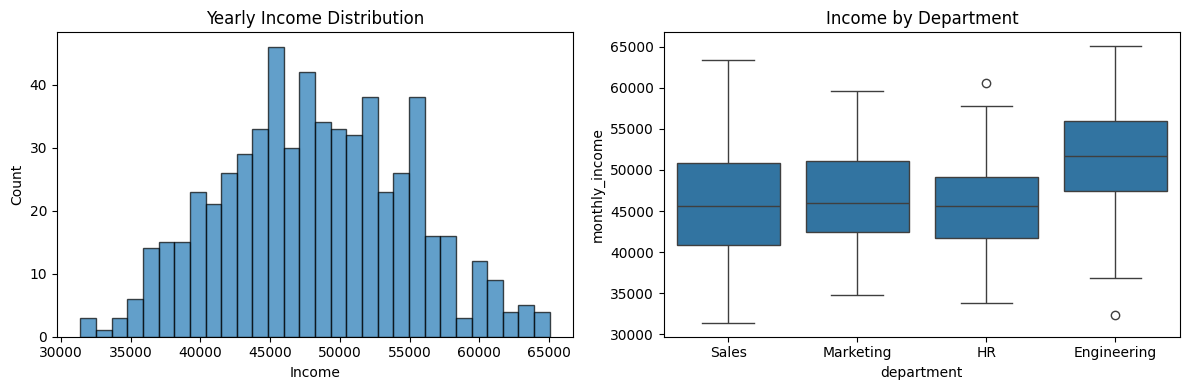

In [ ]:
# STEP 3b: Distribution of the continuous target (Yearly_income)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Yearly_income"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_title("Yearly Income Distribution")
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Count")

sns.boxplot(x="department", y="Yearly_income", data=df, ax=axes[1])
axes[1].set_title("Income by Department")

plt.tight_layout()
plt.show()

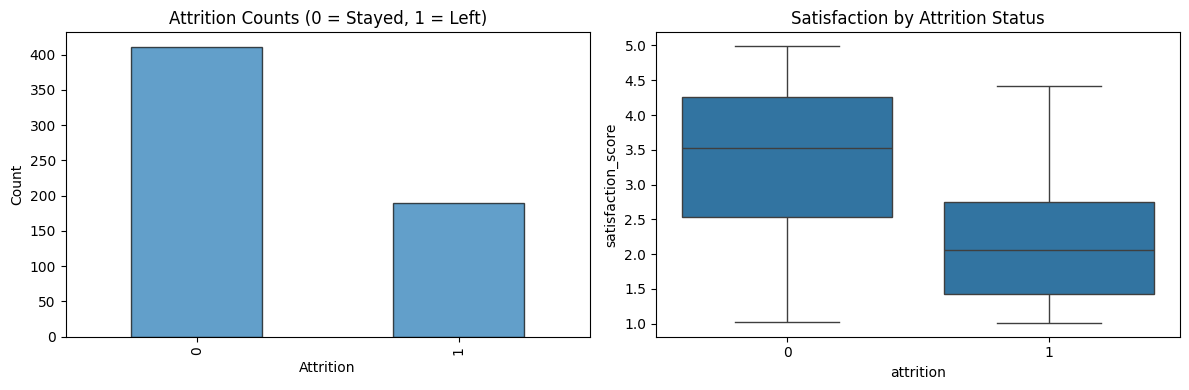

In [91]:
# STEP 3c: Distribution of the binary target (attrition)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["attrition"].value_counts().plot.bar(ax=axes[0], edgecolor="black", alpha=0.7)
axes[0].set_title("Attrition Counts (0 = Stayed, 1 = Left)")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Count")

sns.boxplot(x="attrition", y="satisfaction_score", data=df, ax=axes[1])
axes[1].set_title("Satisfaction by Attrition Status")

plt.tight_layout()
plt.show()

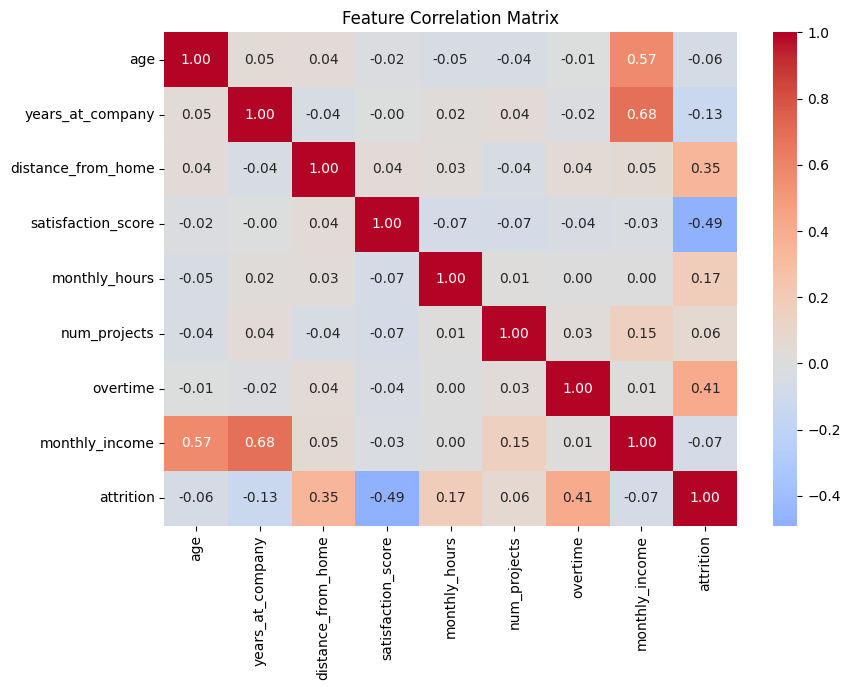

In [92]:
# STEP 3d: Correlation heatmap (numeric columns only)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "employee_id"]

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## STEP 4 -- Feature Engineering and Preprocessing (13 minutes)

In [ ]:
# STEP 4a: Separate features and targets
from sklearn.model_selection import train_test_split

feature_cols = [
    "age", "years_at_company", "distance_from_home",
    "satisfaction_score", "Yearly_hours", "num_projects", "overtime"
]

X = df[feature_cols].copy()
y_income = df["Yearly_income"].copy()
y_attrition = df["attrition"].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Income target shape:  {y_income.shape}")
print(f"Attrition target shape: {y_attrition.shape}")

Feature matrix shape: (600, 7)
Income target shape:  (600,)
Attrition target shape: (600,)


In [151]:
# STEP 4b: Train-test split -- BEFORE any scaling
# The same split is used for BOTH tasks so results are comparable
X_train, X_test, y_inc_train, y_inc_test, y_att_train, y_att_test = train_test_split(
    X, y_income, y_attrition,
    test_size=0.2,
    random_state=SEED,
    stratify=y_attrition
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Train attrition rate: {y_att_train.mean():.2%}")
print(f"Test  attrition rate: {y_att_test.mean():.2%}")

Training set: 480 rows
Test set:     120 rows
Train attrition rate: 31.46%
Test  attrition rate: 31.67%


In [152]:
# STEP 4c: Scale numeric features AFTER splitting
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaler fit on training data only.")
print(f"Train means (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Test means  (will NOT be 0): {X_test_scaled.mean(axis=0).round(4)}")

Scaler fit on training data only.
Train means (should be ~0): [-0. -0.  0.  0.  0. -0. -0.]
Test means  (will NOT be 0): [ 0.0307  0.1412 -0.0952 -0.0602  0.1715 -0.1199  0.0215]


## Stage 2: Building Supervised Models -- Linear Regression and Logistic Regression

## STEP 5 -- Linear Regression: Predicting Yearly Income (15 minutes)

In [153]:
# STEP 5a: Train a Linear Regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_inc_train)

y_inc_pred = lr_model.predict(X_test_scaled)

print("--- Linear Regression: Income Prediction ---")
print(f"R-squared:           {r2_score(y_inc_test, y_inc_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_inc_test, y_inc_pred):.2f}")
print(f"Root Mean Sq Error:  {np.sqrt(mean_squared_error(y_inc_test, y_inc_pred)):.2f}")

--- Linear Regression: Income Prediction ---
R-squared:           0.7231
Mean Absolute Error: 2859.20
Root Mean Sq Error:  3334.72


In [156]:
# STEP 5b: Inspect model coefficients
coeff_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr_model.coef_
}).sort_values("coefficient", ascending=False)

print("\nFeature Coefficients (standardized scale):")
print(coeff_df.to_string(index=False))
print(f"\nIntercept: {lr_model.intercept_:.2f}")


Feature Coefficients (standardized scale):
           feature  coefficient
  years_at_company  4423.194726
               age  3746.611314
      num_projects  1058.139542
distance_from_home   414.966551
          overtime    59.226462
     monthly_hours   -21.075163
satisfaction_score   -21.155370

Intercept: 48083.45


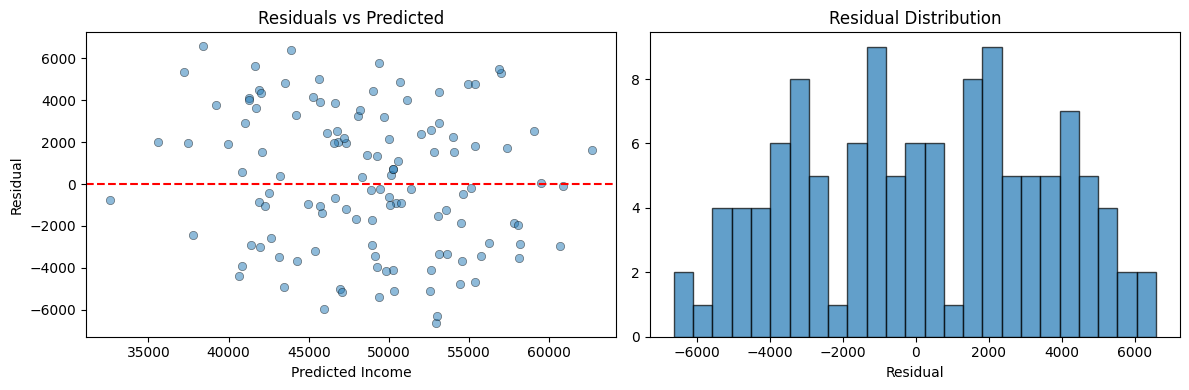

In [157]:
# STEP 5c: Residual analysis
residuals = y_inc_test - y_inc_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_inc_pred, residuals, alpha=0.5, edgecolors="black", linewidth=0.5)
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Income")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=25, edgecolor="black", alpha=0.7)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

## STEP 6 -- Logistic Regression: Predicting Attrition (18 minutes)

In [158]:
# STEP 6a: Train a Logistic Regression model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=SEED, max_iter=1000)
log_model.fit(X_train_scaled, y_att_train)

y_att_pred = log_model.predict(X_test_scaled)
y_att_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained.")
print(f"Classes: {log_model.classes_}")

Logistic Regression trained.
Classes: [0 1]


In [159]:
# STEP 6b: Classification metrics -- NOT just accuracy
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("--- Logistic Regression: Attrition Prediction ---")
print(f"Accuracy:  {accuracy_score(y_att_test, y_att_pred):.4f}")
print(f"Precision: {precision_score(y_att_test, y_att_pred):.4f}")
print(f"Recall:    {recall_score(y_att_test, y_att_pred):.4f}")
print(f"F1 Score:  {f1_score(y_att_test, y_att_pred):.4f}")
print("\nFull Classification Report:")
print(classification_report(y_att_test, y_att_pred, target_names=["Stayed", "Left"]))

--- Logistic Regression: Attrition Prediction ---
Accuracy:  0.9417
Precision: 0.9189
Recall:    0.8947
F1 Score:  0.9067

Full Classification Report:
              precision    recall  f1-score   support

      Stayed       0.95      0.96      0.96        82
        Left       0.92      0.89      0.91        38

    accuracy                           0.94       120
   macro avg       0.94      0.93      0.93       120
weighted avg       0.94      0.94      0.94       120



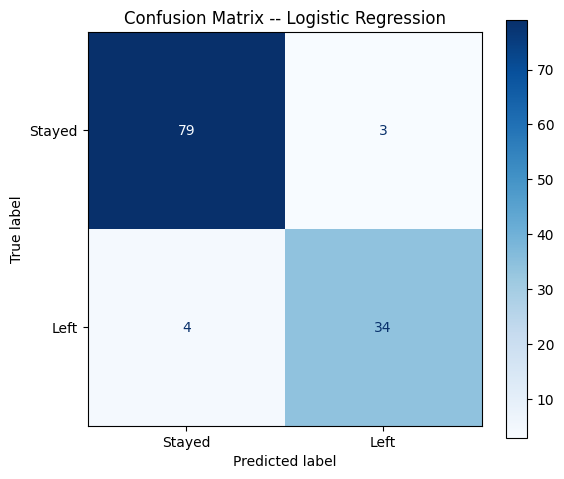

In [160]:
# STEP 6c: Confusion matrix visualization
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    log_model, X_test_scaled, y_att_test,
    display_labels=["Stayed", "Left"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Confusion Matrix -- Logistic Regression")
plt.tight_layout()
plt.show()

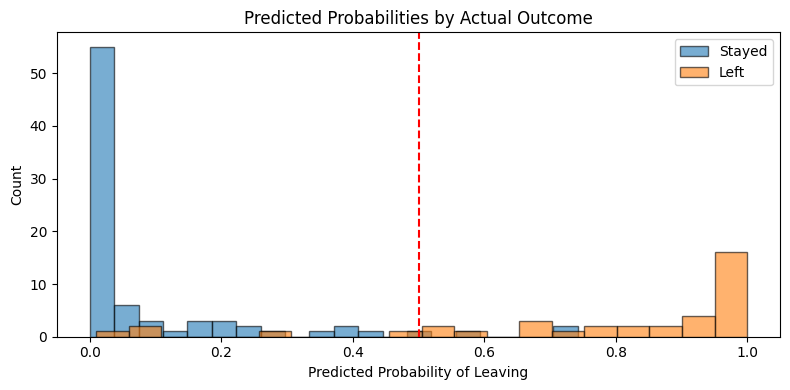

In [162]:
# STEP 6d: Probability distribution for predicted attrition
fig, ax = plt.subplots(figsize=(8, 4))
for label, name in [(0, "Stayed"), (1, "Left")]:
    mask = y_att_test == label
    ax.hist(y_att_proba[mask], bins=20, alpha=0.6, label=name, edgecolor="black")

ax.set_xlabel("Predicted Probability of Leaving")
ax.set_ylabel("Count")
ax.set_title("Predicted Probabilities by Actual Outcome")
ax.legend()
ax.axvline(x=0.5, color="red", linestyle="--", label="Default Threshold")
plt.tight_layout()
plt.show()

## Stage 3: Algorithm Selection, Unsupervised Exploration, and Git Workflow

## STEP 7 -- Baseline Comparison: DummyClassifier (10 minutes)

In [164]:
# STEP 7a: Build a DummyClassifier baseline
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy_model.fit(X_train_scaled, y_att_train)

y_dummy_pred = dummy_model.predict(X_test_scaled)

print("--- Dummy Classifier (Always Predicts Majority Class) ---")
print(f"Accuracy:  {accuracy_score(y_att_test, y_dummy_pred):.4f}")
print(f"Precision: {precision_score(y_att_test, y_dummy_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_att_test, y_dummy_pred, zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_att_test, y_dummy_pred, zero_division=0):.4f}")

--- Dummy Classifier (Always Predicts Majority Class) ---
Accuracy:  0.6833
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000


In [165]:
# STEP 7b: Side-by-side comparison
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "DummyClassifier": [
        accuracy_score(y_att_test, y_dummy_pred),
        precision_score(y_att_test, y_dummy_pred, zero_division=0),
        recall_score(y_att_test, y_dummy_pred, zero_division=0),
        f1_score(y_att_test, y_dummy_pred, zero_division=0),
    ],
    "LogisticRegression": [
        accuracy_score(y_att_test, y_att_pred),
        precision_score(y_att_test, y_att_pred),
        recall_score(y_att_test, y_att_pred),
        f1_score(y_att_test, y_att_pred),
    ],
})

print("--- Model Comparison ---")
print(comparison.to_string(index=False))

--- Model Comparison ---
   Metric  DummyClassifier  LogisticRegression
 Accuracy         0.683333            0.941667
Precision         0.000000            0.918919
   Recall         0.000000            0.894737
       F1         0.000000            0.906667


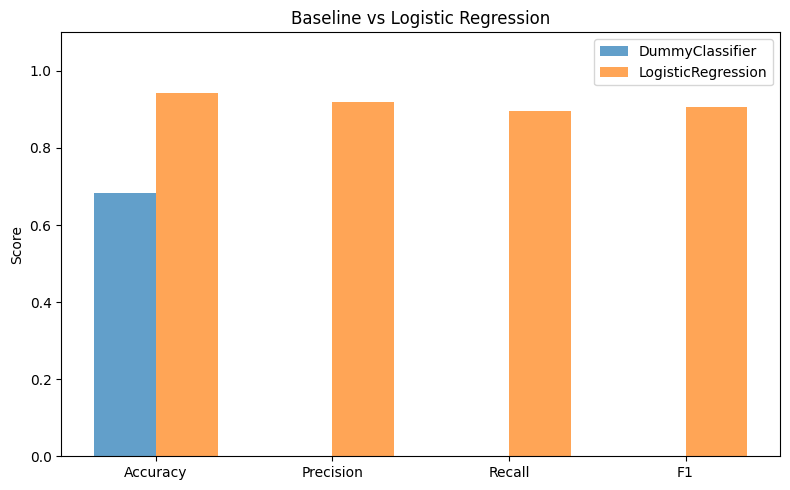

In [166]:
# STEP 7c: Visualize the comparison
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(comparison["Metric"]))
width = 0.35

bars1 = ax.bar(x_pos - width / 2, comparison["DummyClassifier"], width, label="DummyClassifier", alpha=0.7)
bars2 = ax.bar(x_pos + width / 2, comparison["LogisticRegression"], width, label="LogisticRegression", alpha=0.7)

ax.set_xticks(x_pos)
ax.set_xticklabels(comparison["Metric"])
ax.set_ylabel("Score")
ax.set_title("Baseline vs Logistic Regression")
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

## STEP 8 -- Algorithm Selection Framework Walkthrough (8 minutes)

In [ ]:
# STEP 8: Document the algorithm selection reasoning
framework_summary = """
=== ALGORITHM SELECTION FRAMEWORK -- TalentFlow Attrition ===

1. TASK TYPE
   - Supervised binary classification (predict attrition: 0 or 1)
   - Supervised regression (predict Yearly income: continuous)

2. DATA DESCRIPTION
   - 600 rows, 7 numeric features (tabular)
   - No missing values, moderate noise
   - Relationships are approximately linear by construction
   - Binary target has mild class imbalance

3. CONSTRAINTS
   - Interpretability required (HR stakeholders need explanations)
   - Low latency not critical (batch predictions, not real-time)
   - Small team, so model maintenance cost matters

4. BASELINES
   - DummyClassifier (most_frequent): floor for classification
   - LinearRegression: baseline for regression
   - LogisticRegression: baseline for classification

5. RESULTS AND DECISION
   - DummyClassifier: high accuracy, zero recall (useless for the business goal)
   - LogisticRegression: strong improvement in recall and F1
   - LinearRegression: reasonable R-squared with interpretable coefficients
   - DECISION: LogisticRegression is justified for classification;
     LinearRegression is justified for regression.
   - NEXT STEP (future modules): try tree-based ensembles if linear
     models plateau on more complex data.
"""
print(framework_summary)


=== ALGORITHM SELECTION FRAMEWORK -- TalentFlow Attrition ===

1. TASK TYPE
   - Supervised binary classification (predict attrition: 0 or 1)
   - Supervised regression (predict monthly income: continuous)

2. DATA DESCRIPTION
   - 600 rows, 7 numeric features (tabular)
   - No missing values, moderate noise
   - Relationships are approximately linear by construction
   - Binary target has mild class imbalance

3. CONSTRAINTS
   - Interpretability required (HR stakeholders need explanations)
   - Low latency not critical (batch predictions, not real-time)
   - Small team, so model maintenance cost matters

4. BASELINES
   - DummyClassifier (most_frequent): floor for classification
   - LinearRegression: baseline for regression
   - LogisticRegression: baseline for classification

5. RESULTS AND DECISION
   - DummyClassifier: high accuracy, zero recall (useless for the business goal)
   - LogisticRegression: strong improvement in recall and F1
   - LinearRegression: reasonable R-square

## STEP 9 -- Unsupervised Learning: K-Means Clustering (12 minutes)

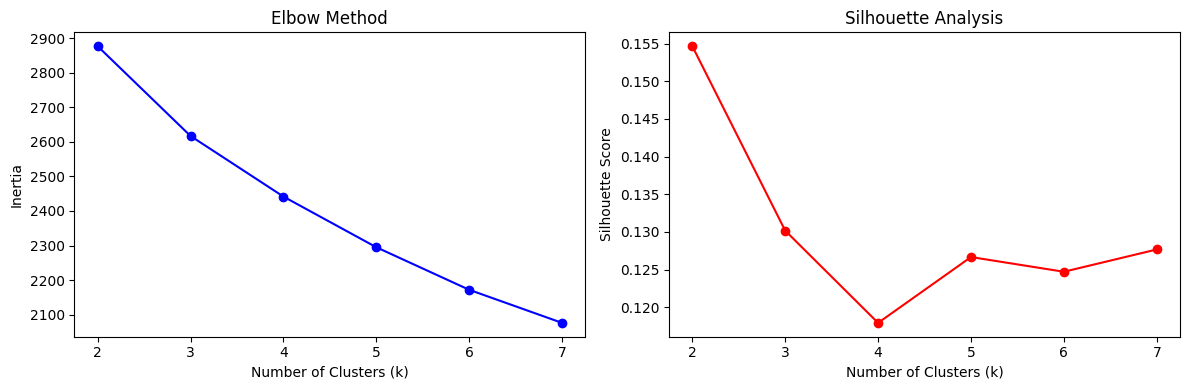


Best k by silhouette score: 2
  k=2: silhouette=0.1547
  k=3: silhouette=0.1302
  k=4: silhouette=0.1179
  k=5: silhouette=0.1267
  k=6: silhouette=0.1247
  k=7: silhouette=0.1277


In [168]:
# STEP 9a: Determine optimal cluster count with Elbow + Silhouette analysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, "bo-")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(K_range), sil_scores, "ro-")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nBest k by silhouette score: {best_k}")
for k, s in zip(K_range, sil_scores):
    print(f"  k={k}: silhouette={s:.4f}")

In [77]:
# STEP 9b: K-Means clustering with data-driven k
kmeans = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
kmeans.fit(X_train_scaled)

cluster_labels = kmeans.predict(X_train_scaled)
print(f"Using k={best_k} clusters")
print(f"Cluster sizes: {np.bincount(cluster_labels)}")

Using k=2 clusters
Cluster sizes: [195 285]


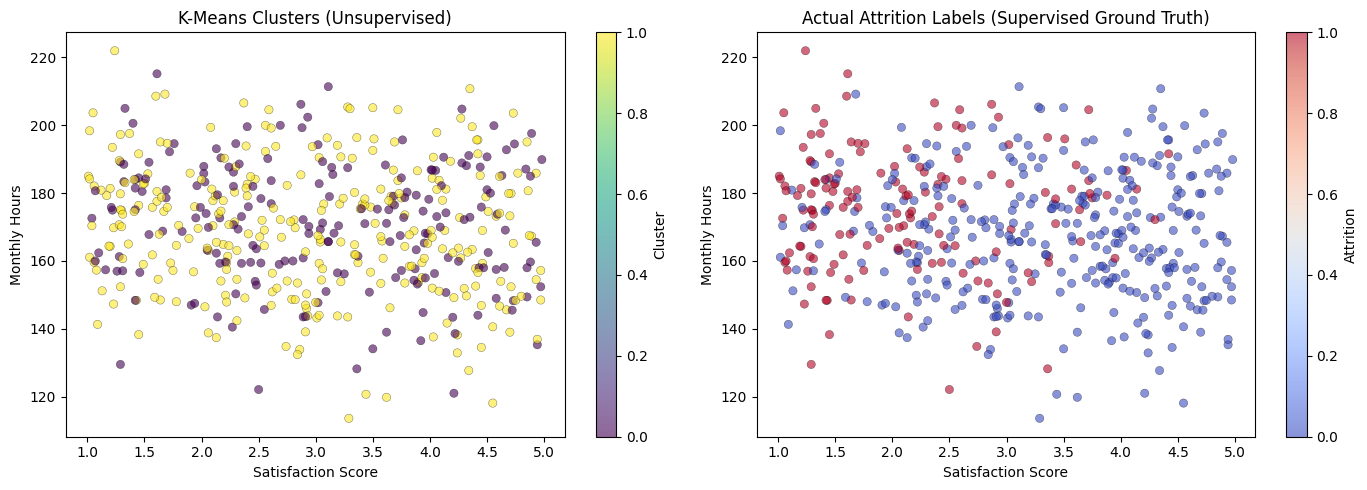

In [ ]:
# STEP 9c: Visualize clusters using the two most informative features
train_df = X_train.copy()
train_df["cluster"] = cluster_labels
train_df["actual_attrition"] = y_att_train.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(
    train_df["satisfaction_score"], train_df["Yearly_hours"],
    c=train_df["cluster"], cmap="viridis", alpha=0.6, edgecolors="black", linewidth=0.3
)
axes[0].set_xlabel("Satisfaction Score")
axes[0].set_ylabel("Yearly Hours")
axes[0].set_title("K-Means Clusters (Unsupervised)")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

scatter2 = axes[1].scatter(
    train_df["satisfaction_score"], train_df["Yearly_hours"],
    c=train_df["actual_attrition"], cmap="coolwarm", alpha=0.6, edgecolors="black", linewidth=0.3
)
axes[1].set_xlabel("Satisfaction Score")
axes[1].set_ylabel("Yearly Hours")
axes[1].set_title("Actual Attrition Labels (Supervised Ground Truth)")
plt.colorbar(scatter2, ax=axes[1], label="Attrition")

plt.tight_layout()
plt.show()

In [ ]:
# STEP 9c: Cross-tabulate clusters with actual attrition
crosstab = pd.crosstab(
    train_df["cluster"], train_df["actual_attrition"],
    rownames=["Cluster"], colnames=["Attrition"]
)
print("Cluster vs Actual Attrition:")
print(crosstab)
print()

for cluster_id in sorted(train_df["cluster"].unique()):
    cluster_mask = train_df["cluster"] == cluster_id
    att_rate = train_df.loc[cluster_mask, "actual_attrition"].mean()
    print(f"Cluster {cluster_id}: {cluster_mask.sum()} employees, attrition rate = {att_rate:.2%}")

Cluster vs Actual Attrition:
Attrition    0    1
Cluster            
0           84  111
1          230   55

Cluster 0: 195 employees, attrition rate = 56.92%
Cluster 1: 285 employees, attrition rate = 19.30%


## STEP 10 -- Git Workflow and Version Control (8 minutes)

**Terminal command:**
```bash
# STEP 10a: Verify we are in the project directory with a git repo
cd talentflow-ml
git status
```

**Terminal command:**
```bash
# STEP 10b: Create a meaningful .gitignore
echo "__pycache__/
*.pyc
.ipynb_checkpoints/
.DS_Store" > .gitignore
```

**Terminal command:**
```bash
# STEP 10c: Stage and commit the initial work
git add .gitignore talentflow_foundations.ipynb
git commit -m "Add foundations notebook: EDA, Linear Reg, Logistic Reg, KMeans baseline"
```

**Terminal command:**
```bash
# STEP 10d: Create an experiment branch
git checkout -b experiment/add-polynomial-features
```

**Terminal command:**
```bash
# STEP 10e: Show branch list
git branch
```

**Terminal command:**
```bash
# STEP 10f: Switch back to main
git checkout main
```

## Git Branch Activity (Remaining Buffer Time)

**Terminal command:**
```bash
   git checkout -b experiment/your-initials-kmeans-test
```

**Terminal command:**
```bash
   git add talentflow_foundations.ipynb
   git commit -m "Experiment: test 4 clusters in KMeans segmentation"
```

**Terminal command:**
```bash
   git checkout main
```